# 🚗 Tesla Stock Price Forecasting — End-to-End LSTM Pipeline
**Dataset:** Tesla Stocks 2010-2025 (Kaggle)  
**Models:** Stacked LSTM · Bidirectional LSTM · GRU  
**Stack:** TensorFlow/Keras · scikit-learn · pandas · matplotlib

---


## 0 · Imports & Configuration

In [4]:
pip install opendatasets

In [7]:
import opendatasets as od
od.download("https://www.kaggle.com/datasets/iamtanmayshukla/tesla-stocks-dataset")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: amralqadi
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/iamtanmayshukla/tesla-stocks-dataset


100%|██████████| 192k/192k [00:00<00:00, 293kB/s]

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, GRU, Bidirectional, Dense, Dropout, Input
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Plot theme (dark / GitHub-dark palette)
plt.rcParams.update({
    "figure.facecolor": "#0d1117",
    "axes.facecolor":   "#161b22",
    "axes.edgecolor":   "#30363d",
    "axes.labelcolor":  "#c9d1d9",
    "xtick.color":      "#8b949e",
    "ytick.color":      "#8b949e",
    "text.color":       "#c9d1d9",
    "grid.color":       "#21262d",
    "grid.linewidth":   0.8,
    "lines.linewidth":  1.6,
    "font.family":      "monospace",
})

ACCENT, ACCENT2, ACCENT3 = "#58a6ff", "#f78166", "#56d364"

print(f"TensorFlow  : {tf.__version__}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")


TensorFlow  : 2.19.0
NumPy       : 2.0.2
Pandas      : 2.2.2


## 1 · Data Loading & Cleaning
- Parse `Date` → `datetime`, set as index  
- Sort chronologically  
- Forward/back-fill any missing values


In [8]:
def load_and_clean(filepath: str) -> pd.DataFrame:
    df = pd.read_csv('/content/tesla-stocks-dataset/tsla_2025.csv', parse_dates=["Date"])
    df.set_index("Date", inplace=True)
    df.sort_index(inplace=True)

    df.columns = [c.strip().title() for c in df.columns]
    expected = ["Open", "High", "Low", "Close", "Volume"]
    df = df[[c for c in expected if c in df.columns]]

    missing_before = df.isnull().sum().sum()
    df.ffill(inplace=True)
    df.bfill(inplace=True)

    print(f"Shape          : {df.shape}")
    print(f"Date range     : {df.index.min().date()} → {df.index.max().date()}")
    print(f"Missing filled : {missing_before} cells")
    return df

# ── CHANGE PATH TO YOUR FILE ──────────────────────────────────────────
df_raw = load_and_clean("tesla_stock.csv")
df_raw.describe().round(2)


Shape          : (3663, 5)
Date range     : 2010-06-28 → 2025-01-17
Missing filled : 0 cells


,Open,High,Low,Close,Volume
count,3663.00,3663.00,3663.00,3663.00,3.663000e+03
mean,82.51,84.36,80.57,82.50,9.611352e+07
std,108.96,111.48,106.29,108.91,7.778909e+07
min,1.08,1.11,0.54,1.05,0.000000e+00
25%,12.18,12.40,11.87,12.14,4.733607e+07
50%,17.99,18.32,17.73,17.98,8.152521e+07
75%,179.50,183.64,175.49,179.82,1.216591e+08
max,475.90,488.54,457.51,479.86,9.140814e+08


## 2 · Exploratory Data Analysis
Key insights:
- Close/Open/High/Low are nearly perfectly correlated — expected for price levels.  
- Volume has weak correlation with price — valuable as auxiliary signal.  
- Strong uptrend post-2020 with extreme volatility 2021–2022.


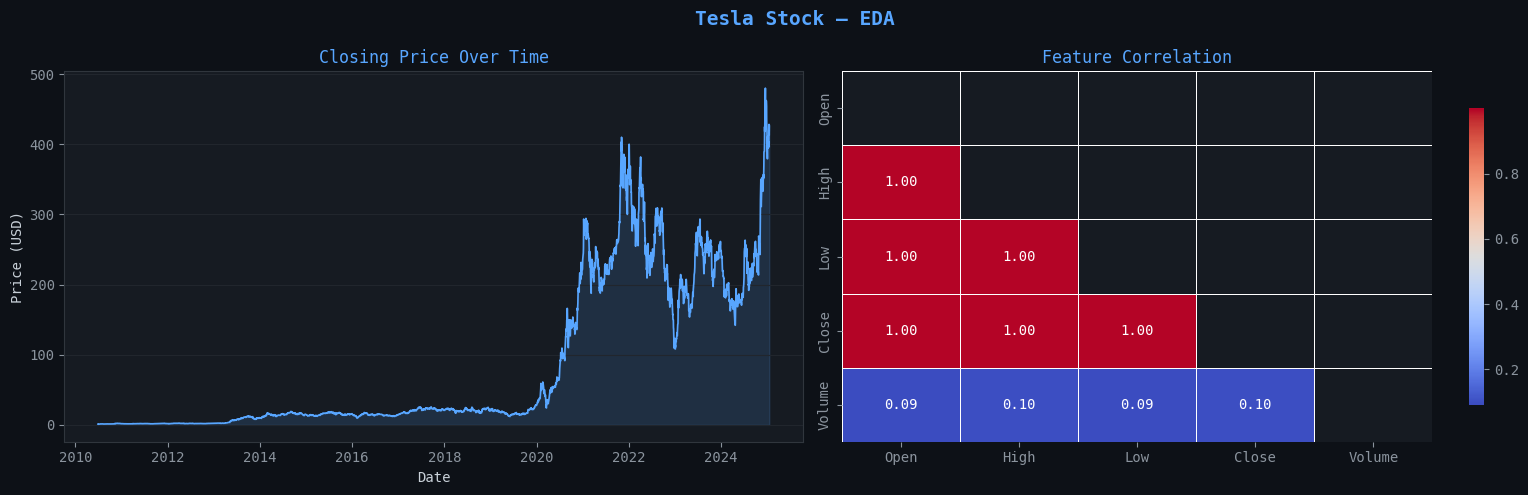

In [9]:
def run_eda(df):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Tesla Stock — EDA", fontsize=14, color=ACCENT, fontweight="bold")

    ax = axes[0]
    ax.plot(df.index, df["Close"], color=ACCENT, linewidth=1.2)
    ax.fill_between(df.index, df["Close"], alpha=0.15, color=ACCENT)
    ax.set_title("Closing Price Over Time", color=ACCENT)
    ax.set_xlabel("Date"); ax.set_ylabel("Price (USD)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.grid(True, axis="y")

    corr = df.corr()
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(
        corr, mask=mask, annot=True, fmt=".2f", ax=axes[1],
        cmap="coolwarm", linewidths=0.5,
        annot_kws={"size": 10, "color": "white"},
        cbar_kws={"shrink": 0.8},
    )
    axes[1].set_title("Feature Correlation", color=ACCENT)
    plt.tight_layout(); plt.show()

run_eda(df_raw)


## 3 · Feature Engineering
| Feature | Description |
|---------|-------------|
| MA10 / MA50 | Rolling mean over 10 / 50 days |
| EMA20 | Exponential moving average (span=20) |
| RSI14 | Relative Strength Index (14-day) |
| Lag 1/2/3/5/10 | Previous close prices |
| Return_1d | 1-day percentage change |


In [10]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-10)
    return 100 - (100 / (1 + rs))

def add_features(df):
    df = df.copy()
    df["MA10"]     = df["Close"].rolling(10).mean()
    df["MA50"]     = df["Close"].rolling(50).mean()
    df["EMA20"]    = df["Close"].ewm(span=20, adjust=False).mean()
    df["RSI14"]    = compute_rsi(df["Close"])
    for lag in [1, 2, 3, 5, 10]:
        df[f"Lag_{lag}"] = df["Close"].shift(lag)
    df["Return_1d"] = df["Close"].pct_change()
    df.dropna(inplace=True)
    print(f"Shape after feature engineering : {df.shape}")
    return df

df_feat = add_features(df_raw)
df_feat.tail(3)


Shape after feature engineering : (3614, 15)


,Open,High,Low,Close,Volume,MA10,MA50,EMA20,RSI14,Lag_1,Lag_2,Lag_3,Lag_5,Lag_10,Return_1d
Date,,,,,,,,,,,,,,,
2025-01-15,409.90,429.80,405.661,428.22,81375460,401.654,374.2456,407.180114,49.436820,396.36,403.31,394.74,394.36,417.41,0.080381
2025-01-16,423.49,424.00,409.130,413.82,68335151,402.652,377.5424,407.812484,37.511597,428.22,396.36,403.31,394.94,403.84,-0.033628
2025-01-17,421.50,439.74,419.750,426.50,94991429,407.374,381.2156,409.592247,43.042055,413.82,428.22,396.36,394.74,379.28,0.030641


## 4 · Data Preprocessing
- `MinMaxScaler` maps every feature to [0, 1]  
- Target column (`Close`) sits at `target_idx` inside the feature matrix  
- Full scaled array shape: `(n_rows, n_features)`


In [11]:
def preprocess(df, target_col="Close"):
    feature_cols = list(df.columns)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(df[feature_cols])
    target_idx = feature_cols.index(target_col)
    print(f"Features  : {feature_cols}")
    print(f"Target idx: {target_idx} ({target_col})")
    print(f"Scaled shape: {scaled.shape}")
    return scaled, scaler, feature_cols, target_idx

scaled, scaler, feature_cols, target_idx = preprocess(df_feat)
n_features = len(feature_cols)


Features  : ['Open', 'High', 'Low', 'Close', 'Volume', 'MA10', 'MA50', 'EMA20', 'RSI14', 'Lag_1', 'Lag_2', 'Lag_3', 'Lag_5', 'Lag_10', 'Return_1d']
Target idx: 3 (Close)
Scaled shape: (3614, 15)


## 5 · Sequence Creation (Sliding Window)
- `time_steps = 60` — use 60 trading days to predict next close  
- **X shape:** `(samples, 60, n_features)` — 3-D tensor for LSTM  
- **y shape:** `(samples,)` — single scalar target


In [12]:
def create_sequences(data, target_idx, time_steps=60):
    X, y = [], []
    for i in range(time_steps, len(data)):
        X.append(data[i - time_steps: i, :])
        y.append(data[i, target_idx])
    X, y = np.array(X), np.array(y)
    print(f"X shape: {X.shape}  |  y shape: {y.shape}")
    return X, y

TIME_STEPS = 60
X, y = create_sequences(scaled, target_idx, TIME_STEPS)


X shape: (3554, 60, 15)  |  y shape: (3554,)


## 6 · Train / Validation / Test Split
- **80 %** train (chronological) — last 10 % of that used as validation  
- **20 %** test  
- ⚠️ No shuffling — time-series order must be preserved


In [13]:
def split_data(X, y, split=0.80):
    cut = int(len(X) * split)
    return X[:cut], X[cut:], y[:cut], y[cut:]

X_train, X_test, y_train, y_test = split_data(X, y)

val_cut = int(len(X_train) * 0.90)
X_val, y_val       = X_train[val_cut:], y_train[val_cut:]
X_train, y_train   = X_train[:val_cut], y_train[:val_cut]

print(f"Train : {X_train.shape}  |  Val: {X_val.shape}  |  Test: {X_test.shape}")
input_shape = (TIME_STEPS, n_features)


Train : (2558, 60, 15)  |  Val: (285, 60, 15)  |  Test: (711, 60, 15)


## 7 · Model Architectures
Three models trained and compared:

| Model | Architecture | Params |
|-------|-------------|--------|
| Stacked LSTM | 2× LSTM(64) + Dropout | ~baseline |
| Bidirectional LSTM | 2× BiLSTM(64) + Dropout | ~2× LSTM |
| GRU | 2× GRU(64) + Dropout | ~¾ LSTM |


In [14]:
def build_lstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(64),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1),
    ], name="Stacked_LSTM")
    model.compile(optimizer="adam", loss="mean_squared_error")
    return model

def build_bilstm(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.2),
        Bidirectional(LSTM(64)),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1),
    ], name="Bidirectional_LSTM")
    model.compile(optimizer="adam", loss="mean_squared_error")
    return model

def build_gru(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(64, return_sequences=True),
        Dropout(0.2),
        GRU(64),
        Dropout(0.2),
        Dense(32, activation="relu"),
        Dense(1),
    ], name="GRU")
    model.compile(optimizer="adam", loss="mean_squared_error")
    return model

lstm_model   = build_lstm(input_shape);  lstm_model.summary()
bilstm_model = build_bilstm(input_shape)
gru_model    = build_gru(input_shape)


Model: "Stacked_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 64)         │        20,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,617 (217.25 KB)

 Trainable params: 55,617 (217.25 KB)

 Non-trainable params: 0 (0.00 B)

## 8 · Model Training
- `EarlyStopping(patience=10)` — restores best weights automatically  
- `ReduceLROnPlateau(patience=5)` — halves LR on plateau


In [15]:
def train_model(model, X_tr, y_tr, X_v, y_v, epochs=50, batch=32):
    callbacks = [
        EarlyStopping(monitor="val_loss", patience=10,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                          patience=5, min_lr=1e-6, verbose=1),
    ]
    return model.fit(
        X_tr, y_tr,
        validation_data=(X_v, y_v),
        epochs=epochs, batch_size=batch,
        callbacks=callbacks, verbose=1,
    )

EPOCHS, BATCH = 50, 32
print("─"*50, "\n  Stacked LSTM\n", "─"*50)
h_lstm   = train_model(lstm_model,   X_train, y_train, X_val, y_val, EPOCHS, BATCH)

print("─"*50, "\n  Bidirectional LSTM\n", "─"*50)
h_bilstm = train_model(bilstm_model, X_train, y_train, X_val, y_val, EPOCHS, BATCH)

print("─"*50, "\n  GRU\n", "─"*50)
h_gru    = train_model(gru_model,    X_train, y_train, X_val, y_val, EPOCHS, BATCH)


────────────────────────────────────────────────── 
  Stacked LSTM
 ──────────────────────────────────────────────────
Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 7.0141e-04 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 2.3416e-04 - val_loss: 0.0324 - learning_rate: 0.0010
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 4.0789e-04 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 2.3607e-04 - val_loss: 0.0076 - learning_rate: 0.0010
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.9466e-04 - val_loss: 0.0109 - learning_rate: 0.0010
Epoch 6/50
76/80 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.4983e-04
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.5915e-04 - val_loss: 0.0105 - learning_rate: 0.0010
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 1.4320e-04

## 9 · Evaluation — RMSE & MAE

In [16]:
def inverse_close(preds, scaler, n_features, target_idx):
    dummy = np.zeros((len(preds), n_features))
    dummy[:, target_idx] = preds.ravel()
    return scaler.inverse_transform(dummy)[:, target_idx]

def evaluate(model, X_test, y_test, name="Model"):
    y_pred_s = model.predict(X_test, verbose=0)
    y_pred   = inverse_close(y_pred_s, scaler, n_features, target_idx)
    y_true   = inverse_close(y_test,   scaler, n_features, target_idx)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f"[{name:22s}]  RMSE: ${rmse:7.3f}  |  MAE: ${mae:7.3f}")
    return y_true, y_pred, {"model": name, "RMSE": rmse, "MAE": mae}

y_true, y_pred_lstm,   r1 = evaluate(lstm_model,   X_test, y_test, "Stacked LSTM")
_,      y_pred_bilstm, r2 = evaluate(bilstm_model, X_test, y_test, "Bidirectional LSTM")
_,      y_pred_gru,    r3 = evaluate(gru_model,    X_test, y_test, "GRU")


[Stacked LSTM          ]  RMSE: $ 17.216  |  MAE: $ 12.652
[Bidirectional LSTM    ]  RMSE: $ 34.756  |  MAE: $ 30.022
[GRU                   ]  RMSE: $ 14.444  |  MAE: $ 10.862


## 10 · Visualisation

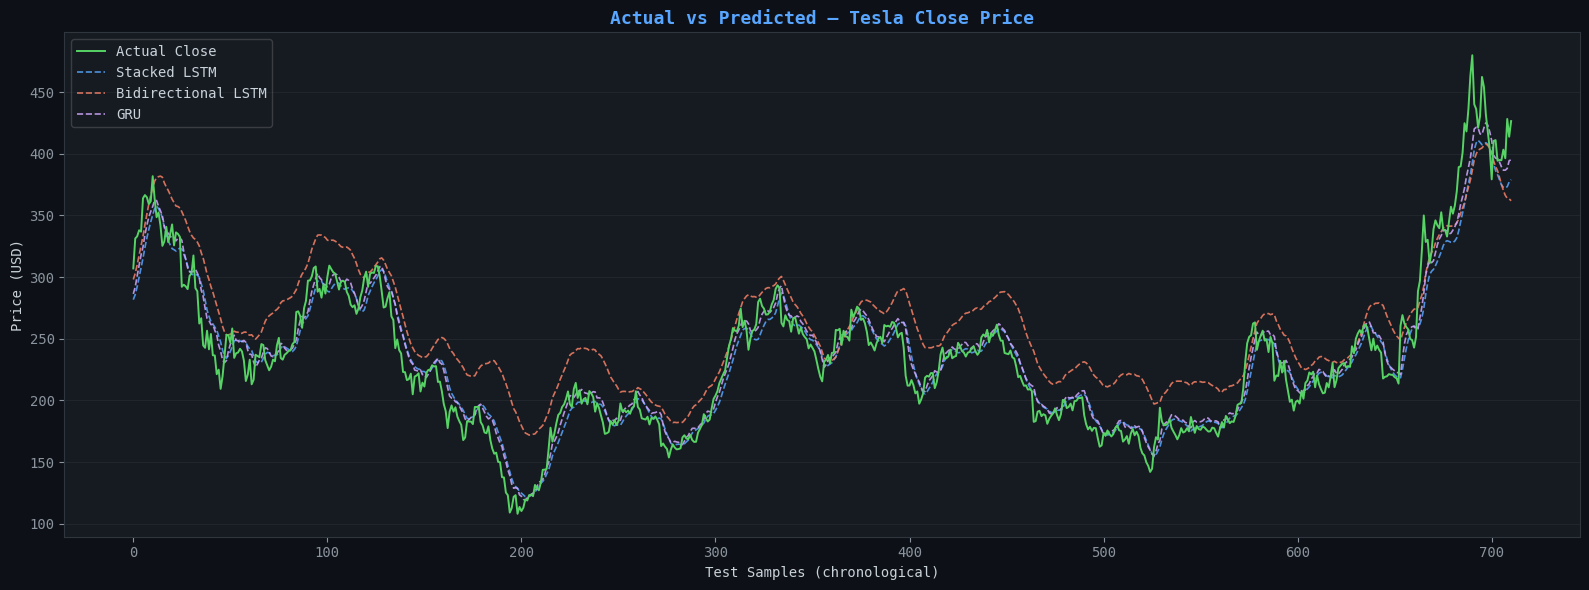

In [17]:
# ── Predictions ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(y_true,        color=ACCENT3, lw=1.4, label="Actual Close", zorder=3)
ax.plot(y_pred_lstm,   color=ACCENT,  lw=1.2, ls="--", label="Stacked LSTM",       alpha=0.85)
ax.plot(y_pred_bilstm, color=ACCENT2, lw=1.2, ls="--", label="Bidirectional LSTM", alpha=0.85)
ax.plot(y_pred_gru,    color="#d2a8ff", lw=1.2, ls="--", label="GRU",              alpha=0.85)
ax.set_title("Actual vs Predicted — Tesla Close Price", fontsize=13, color=ACCENT, fontweight="bold")
ax.set_xlabel("Test Samples (chronological)"); ax.set_ylabel("Price (USD)")
ax.legend(framealpha=0.2); ax.grid(True, axis="y")
plt.tight_layout(); plt.show()


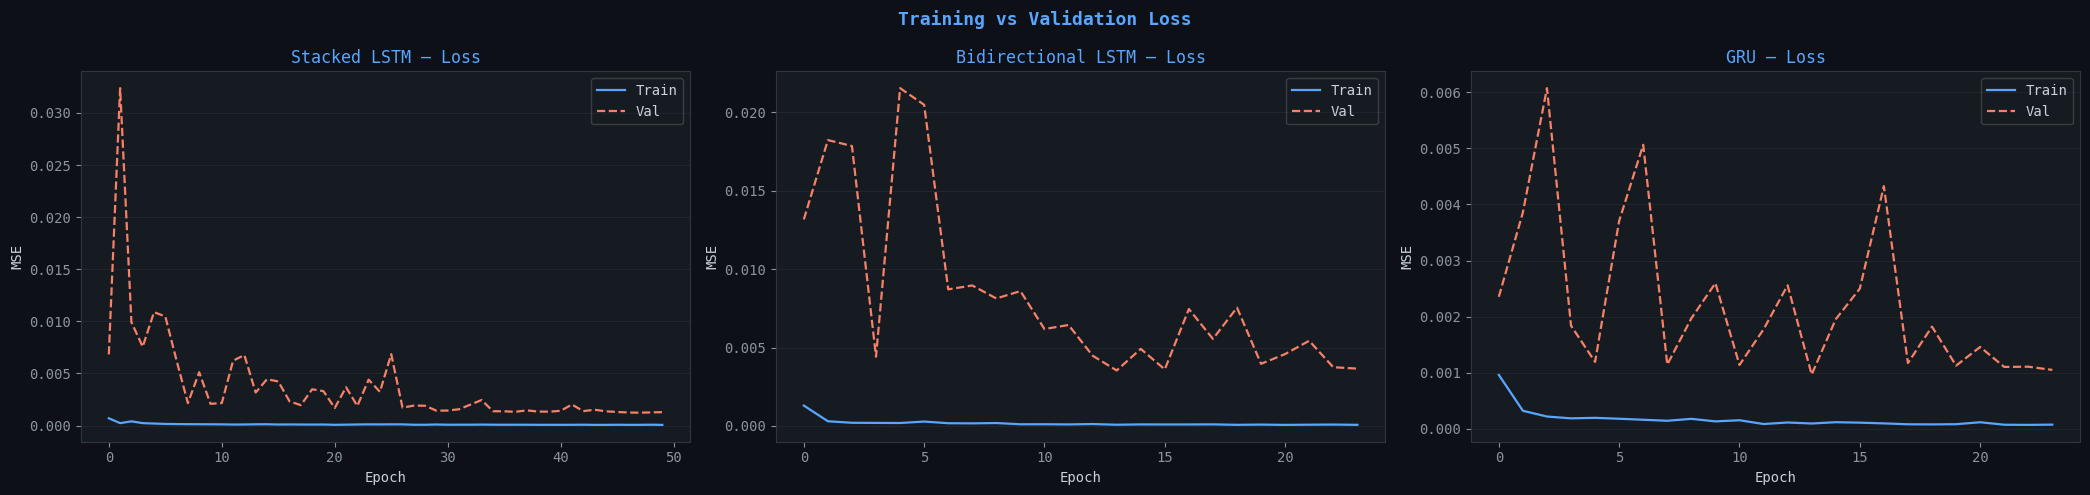

In [18]:
# ── Loss Curves ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
for ax, (name, h) in zip(axes, [("Stacked LSTM", h_lstm),
                                  ("Bidirectional LSTM", h_bilstm),
                                  ("GRU", h_gru)]):
    ax.plot(h.history["loss"],     color=ACCENT,  label="Train")
    ax.plot(h.history["val_loss"], color=ACCENT2, label="Val", ls="--")
    ax.set_title(f"{name} — Loss", color=ACCENT)
    ax.set_xlabel("Epoch"); ax.set_ylabel("MSE"); ax.legend(framealpha=0.2)
    ax.grid(True, axis="y")
plt.suptitle("Training vs Validation Loss", fontsize=13, color=ACCENT, fontweight="bold")
plt.tight_layout(); plt.show()


## 11 · Model Comparison & Bonus Notes
### Bonus Architecture Notes

| Model | Strength | Trade-off |
|-------|----------|-----------|
| **Stacked LSTM** | Strong baseline, widely understood | Unidirectional only |
| **Bidirectional LSTM** | Reads window both ways → richer context | ~2× parameters |
| **GRU** | Fewer params, faster convergence | Slightly less expressive |

**Recommendation:** Use *Bidirectional LSTM* for best accuracy. Use *GRU* when compute or latency is a concern.


In [19]:
results = pd.DataFrame([r1, r2, r3]).set_index("model").sort_values("RMSE")
print("\n" + "="*45)
print("     MODEL PERFORMANCE COMPARISON")
print("="*45)
print(results.round(4).to_string())
print("="*45)
print(f"\n  ✔ Best model by RMSE : {results.index[0]}")



     MODEL PERFORMANCE COMPARISON
                       RMSE      MAE
model                               
GRU                 14.4443  10.8625
Stacked LSTM        17.2159  12.6523
Bidirectional LSTM  34.7562  30.0224

  ✔ Best model by RMSE : GRU


In [20]:
# ── Save models ──────────────────────────────────────────────────────────
lstm_model.save("model_lstm.keras")
bilstm_model.save("model_bilstm.keras")
gru_model.save("model_gru.keras")
print("Models saved: model_lstm.keras | model_bilstm.keras | model_gru.keras")


Models saved: model_lstm.keras | model_bilstm.keras | model_gru.keras
